# 04 — Benchmark de la simulación secuencial

## Objetivo

Medir experimentalmente el tiempo requerido para ejecutar
diferentes cantidades de escenarios mediante la implementación
secuencial.

Se utilizarán:

- 10,000 escenarios.
- 100,000 escenarios.
- 1,000,000 escenarios.

Los tiempos no serán asumidos ni inventados.
Todos los resultados serán obtenidos mediante ejecución real.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from src.data.loader import load_csv

from src.simulation.model import (
    NormalReturnModel,
)

from src.simulation.sequential import (
    SimulationConfig,
    simulate_sequential_final_values,
)

from src.simulation.benchmark import (
    benchmark_simulation,
)

In [4]:
PROCESSED_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "sp500_returns.csv"
)

returns_data = load_csv(
    PROCESSED_DATA_PATH
)

mean_return = (
    returns_data["log_return"].mean()
)

volatility = (
    returns_data["log_return"].std()
)

model = NormalReturnModel(
    mean=mean_return,
    volatility=volatility,
)

In [5]:
HORIZON = 252
INITIAL_VALUE = 100.0
SEED = 42

SCENARIO_COUNTS = [
    10_000,
    100_000,
    1_000_000,
]

print(SCENARIO_COUNTS)

[10000, 100000, 1000000]


In [6]:
test_config = SimulationConfig(
    scenarios=1_000,
    horizon=HORIZON,
    initial_value=INITIAL_VALUE,
    seed=SEED,
)

test_values = (
    simulate_sequential_final_values(
        model=model,
        config=test_config,
    )
)

print(
    "Resultados:",
    len(test_values),
)

Resultados: 1000


In [7]:
benchmark_results = []

for scenario_count in SCENARIO_COUNTS:

    config = SimulationConfig(
        scenarios=scenario_count,
        horizon=HORIZON,
        initial_value=INITIAL_VALUE,
        seed=SEED,
    )

    result = benchmark_simulation(
        simulation_function=lambda config=config: (
            simulate_sequential_final_values(
                model=model,
                config=config,
            )
        ),
        scenarios=scenario_count,
    )

    benchmark_results.append(
        result
    )

    print(
        f"{scenario_count:,} escenarios → "
        f"{result.elapsed_seconds:.4f} segundos"
    )

10,000 escenarios → 0.0974 segundos
100,000 escenarios → 0.7630 segundos
1,000,000 escenarios → 7.7983 segundos


In [8]:
benchmark_table = pd.DataFrame(
    [
        {
            "scenarios": result.scenarios,
            "elapsed_seconds": (
                result.elapsed_seconds
            ),
            "scenarios_per_second": (
                result.scenarios_per_second
            ),
        }
        for result in benchmark_results
    ]
)

benchmark_table

,scenarios,elapsed_seconds,scenarios_per_second
0,10000,0.097351,102721.503513
1,100000,0.763001,131061.495887
2,1000000,7.798265,128233.655262


In [9]:
BENCHMARK_PATH = (
    PROJECT_ROOT
    / "results"
    / "benchmarks"
    / "sequential_benchmark.csv"
)

BENCHMARK_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

benchmark_table.to_csv(
    BENCHMARK_PATH,
    index=False,
)

print(
    f"Guardado en:\n{BENCHMARK_PATH}"
)

Guardado en:
c:\Users\REYES\OneDrive\Desktop\9noSemestre\programacion paralela\analisis riesgo montecarlo\results\benchmarks\sequential_benchmark.csv


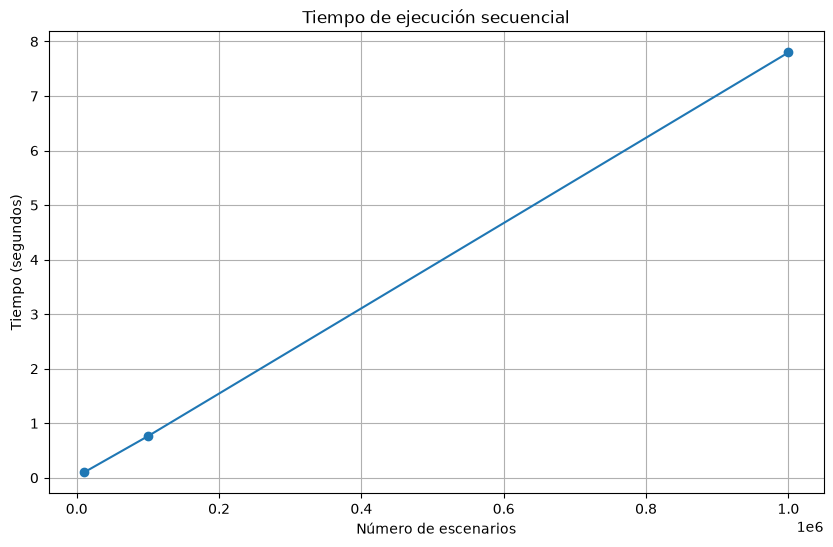

In [10]:
plt.figure(figsize=(10, 6))

plt.plot(
    benchmark_table["scenarios"],
    benchmark_table["elapsed_seconds"],
    marker="o",
)

plt.title(
    "Tiempo de ejecución secuencial"
)

plt.xlabel("Número de escenarios")
plt.ylabel("Tiempo (segundos)")

plt.grid(True)

plt.show()

## Interpretación

El benchmark establece la línea base contra la cual se comparará
posteriormente la implementación paralela.

Los resultados dependen del hardware y de las condiciones de
ejecución del equipo donde se realiza el experimento.